# 08 - Crop Method B Experiment: Isotropic Square 96×96 Lip Crops
## Tai Phake Visual Speech Recognition (VSR) Project

**Objective**: Formulate, generate, and statistically evaluate **Crop Method B** ($96\times 96$ pixels, isotropic square crop) across the entire cleaned Tai Phake dataset ($330$ utterances, $13,610$ frames) using existing Dlib 68 landmark geometry (mouth points 48–67).

---

### Method B Problem Formulation & Specification:
1. **Detect mouth ROI**: Use measured Dlib landmark geometry points 48–67 ($x_{\min}, x_{\max}, y_{\min}, y_{\max}$) and centroid $(c_x, c_y)$.
2. **Apply Padded Mouth ROI**: Standard horizontal and vertical margins ($P_x = 15\text{ px}, P_y = 10\text{ px}$):
   $$w_{\text{mouth}} = w_{\text{raw}} + 2\cdot P_x, \quad h_{\text{mouth}} = h_{\text{raw}} + 2\cdot P_y$$
3. **True Square Bounding Box**:
   $$\text{side} = \lfloor 1.05 \cdot \max(w_{\text{mouth}}, h_{\text{mouth}}) \rceil$$
4. **No Non-Isotropic Distortion**:
   The crop is extracted as a square from the source face image. Resizing to $96\times 96$ scales width and height by the identical ratio ($1.0:1$), preserving natural lip aspect ratios without squashing or vertical elongation.
5. **No Clipping / Boundary Reflection**: If the square extends beyond the video frame boundary, reflective padding is applied.
6. **Save to Dedicated Dataset**: Saved to `data/cropped_lips_dataset_b_96x96/` leaving existing datasets untouched.

> **Constraint**: Do **NOT** train models in this experiment. The objective is data generation, geometric validation, and reporting.

## 1. Setup, Environment & Configuration

In [1]:
# Section 1: Environment & Imports
import os
import sys
import re
import json
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_ROOT = PROJECT_ROOT / "data" / "digit"
GEOMETRY_CSV = PROJECT_ROOT / "results" / "dlib" / "dlib_roi_geometry_all_frames.csv"
OUTPUT_DATASET_B = PROJECT_ROOT / "data" / "cropped_lips_dataset_b_96x96"
RESULTS_DIR = PROJECT_ROOT / "results" / "crop_method_b"

OUTPUT_DATASET_B.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Target Method B Parameters
TARGET_SIZE = 96  # 96x96 square output
PAD_X = 15        # Horizontal lip padding
PAD_Y = 10        # Vertical lip padding
MARGIN_FACTOR = 1.05  # 5% comfort margin

print(f"Project Root:        {PROJECT_ROOT}")
print(f"Raw Face Frames:     {DATA_ROOT}")
print(f"Output Dataset B:    {OUTPUT_DATASET_B}")
print(f"Results Directory:   {RESULTS_DIR}")

Project Root:        /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading
Raw Face Frames:     /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/digit
Output Dataset B:    /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/cropped_lips_dataset_b_96x96
Results Directory:   /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/crop_method_b


## 2. Load Measured Dlib Landmark Geometry (13,610 Frames)

In [2]:
# Section 2: Load Geometry Metadata
df_geom = pd.read_csv(GEOMETRY_CSV)
print(f"Total Frames Indexed: {len(df_geom):,}")
print(f"Dlib Detection Rate:  {df_geom['detected'].sum():,} / {len(df_geom):,} ({df_geom['detected'].mean()*100:.2f}%)")
print(f"Failed Detections:    {(~df_geom['detected']).sum()}")

df_geom[["speaker", "digit", "frame", "raw_width", "raw_height", "raw_aspect_ratio", "center_x", "center_y"]].head(10)

Total Frames Indexed: 13,610
Dlib Detection Rate:  13,610 / 13,610 (100.00%)
Failed Detections:    0


,speaker,digit,frame,raw_width,raw_height,raw_aspect_ratio,center_x,center_y
0,s1,d0,frame_0001.jpg,164,66,2.484848,375.0,756.0
1,s1,d0,frame_0002.jpg,162,69,2.347826,374.0,756.5
2,s1,d0,frame_0003.jpg,161,75,2.146667,374.5,758.5
3,s1,d0,frame_0004.jpg,161,81,1.987654,372.5,758.5
4,s1,d0,frame_0005.jpg,158,87,1.816092,372.0,760.5
5,s1,d0,frame_0006.jpg,159,90,1.766667,371.5,764.0
6,s1,d0,frame_0007.jpg,156,87,1.793103,369.0,765.5
7,s1,d0,frame_0008.jpg,155,72,2.152778,369.5,764.0
8,s1,d0,frame_0009.jpg,157,60,2.616667,366.5,757.0
9,s1,d0,frame_0010.jpg,156,54,2.888889,369.0,756.0


## 3. Geometric Statistics Before Square Cropping
We examine the raw mouth width, height, and natural aspect ratios before constructing the square box.

--- Natural Mouth Landmark Dimensions (Tight Points 48-67) ---
  Width:         Mean = 110.9 px | Median = 113.0 px | Min = 29 px | Max = 179 px
  Height:        Mean = 52.6 px | Median = 51.0 px | Min = 14 px | Max = 141 px
  Raw Ratio:     Mean = 2.21:1 | Median = 2.19:1 | 25th = 1.84:1 | 75th = 2.55:1
  Padded Ratio:  Mean = 1.98:1 | Median = 1.98:1 (With standard pad_x=15, pad_y=10)


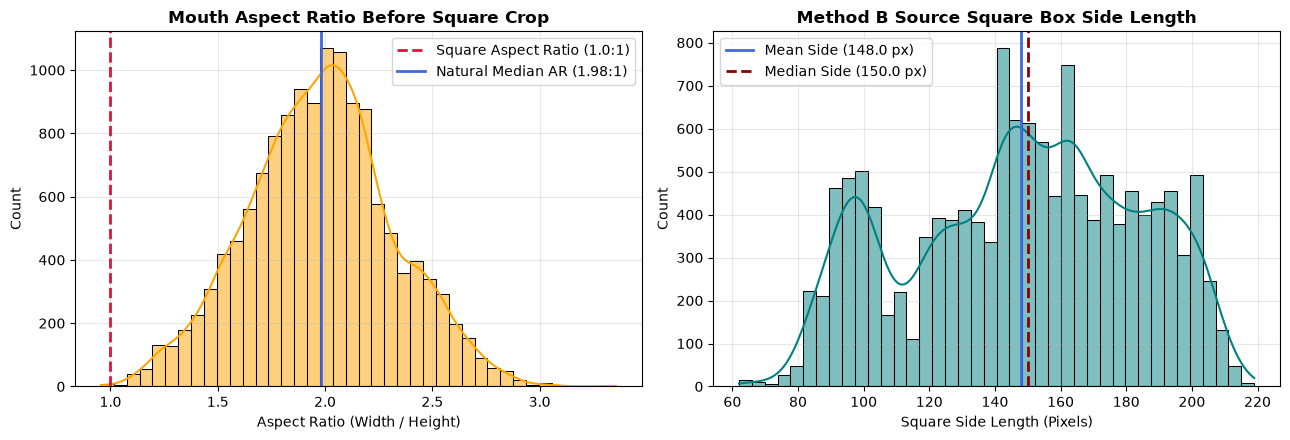

In [3]:
# Section 3: Distribution Analysis
raw_w = df_geom["raw_width"]
raw_h = df_geom["raw_height"]
raw_ar = df_geom["raw_aspect_ratio"]
pad_w = raw_w + 2 * PAD_X
pad_h = raw_h + 2 * PAD_Y
pad_ar = pad_w / pad_h

print("--- Natural Mouth Landmark Dimensions (Tight Points 48-67) ---")
print(f"  Width:         Mean = {raw_w.mean():.1f} px | Median = {raw_w.median():.1f} px | Min = {raw_w.min()} px | Max = {raw_w.max()} px")
print(f"  Height:        Mean = {raw_h.mean():.1f} px | Median = {raw_h.median():.1f} px | Min = {raw_h.min()} px | Max = {raw_h.max()} px")
print(f"  Raw Ratio:     Mean = {raw_ar.mean():.2f}:1 | Median = {raw_ar.median():.2f}:1 | 25th = {raw_ar.quantile(0.25):.2f}:1 | 75th = {raw_ar.quantile(0.75):.2f}:1")
print(f"  Padded Ratio:  Mean = {pad_ar.mean():.2f}:1 | Median = {pad_ar.median():.2f}:1 (With standard pad_x=15, pad_y=10)")

# Visualization of Aspect Ratios and Square Box Side lengths
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(pad_ar, kde=True, ax=axes[0], color="orange", bins=40)
axes[0].axvline(1.0, color="crimson", linestyle="--", lw=2, label="Square Aspect Ratio (1.0:1)")
axes[0].axvline(pad_ar.median(), color="royalblue", linestyle="-", lw=2, label=f"Natural Median AR ({pad_ar.median():.2f}:1)")
axes[0].set_title("Mouth Aspect Ratio Before Square Crop", fontweight="bold")
axes[0].set_xlabel("Aspect Ratio (Width / Height)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sq_sides = np.round(np.maximum(pad_w, pad_h) * MARGIN_FACTOR).astype(int)
sns.histplot(sq_sides, kde=True, ax=axes[1], color="teal", bins=40)
axes[1].axvline(sq_sides.mean(), color="royalblue", linestyle="-", lw=2, label=f"Mean Side ({sq_sides.mean():.1f} px)")
axes[1].axvline(sq_sides.median(), color="darkred", linestyle="--", lw=2, label=f"Median Side ({sq_sides.median():.1f} px)")
axes[1].set_title("Method B Source Square Box Side Length", fontweight="bold")
axes[1].set_xlabel("Square Side Length (Pixels)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "method_b_geometry_distributions.png", dpi=300)
plt.show()

## 4. Formulation of Method B Cropping Algorithm
To avoid any non-isotropic distortion, the source bounding box is calculated as a true square around the mouth centroid $(c_x, c_y)$ with comfort margin:

1. **Center**: $c_x = \frac{x_{\min} + x_{\max}}{2}, \quad c_y = \frac{y_{\min} + y_{\max}}{2}$
2. **Base Mouth Span**: $w_{\text{mouth}} = w_{\text{raw}} + 2\cdot P_x, \quad h_{\text{mouth}} = h_{\text{raw}} + 2\cdot P_y$
3. **Square Side Dimension**:
   $$\text{side} = \lfloor 1.05 \cdot \max(w_{\text{mouth}}, h_{\text{mouth}}) \rceil$$
4. **Coordinates**:
   $$x_1 = \lfloor c_x - \frac{\text{side}}{2} \rceil, \quad y_1 = \lfloor c_y - \frac{\text{side}}{2} \rceil, \quad x_2 = x_1 + \text{side}, \quad y_2 = y_1 + \text{side}$$
5. **Border Reflection**: Applied if bounding coordinates extend beyond frame boundaries.
6. **Resize**: `cv2.resize(crop, (96, 96), interpolation=cv2.INTER_AREA)`.

In [4]:
# Section 4: Method B Geometric Cropping Function
def compute_method_b_bbox(raw_w, raw_h, cx, cy, img_w, img_h):
    w_mouth = raw_w + 2 * PAD_X
    h_mouth = raw_h + 2 * PAD_Y
    
    side = int(round(max(w_mouth, h_mouth) * MARGIN_FACTOR))
    
    x1 = int(round(cx - side / 2.0))
    y1 = int(round(cy - side / 2.0))
    x2 = x1 + side
    y2 = y1 + side
    
    pad_top = max(0, -y1)
    pad_left = max(0, -x1)
    pad_bottom = max(0, y2 - img_h)
    pad_right = max(0, x2 - img_w)
    
    min_x = cx - raw_w / 2.0
    max_x = cx + raw_w / 2.0
    min_y = cy - raw_h / 2.0
    max_y = cy + raw_h / 2.0
    
    is_contained = (x1 <= min_x) and (x2 >= max_x) and (y1 <= min_y) and (y2 >= max_y)
    
    return {
        "box_side": side,
        "aspect_ratio": 1.0,
        "x1": x1, "y1": y1, "x2": x2, "y2": y2,
        "pad_top": pad_top, "pad_bottom": pad_bottom,
        "pad_left": pad_left, "pad_right": pad_right,
        "is_contained": is_contained
    }

print("Method B square bounding box function defined successfully.")

Method B square bounding box function defined successfully.


## 5. Dataset Generation: Process All 330 Utterances (13,610 Frames)
Extract and save Method B square crops for all utterances in the dataset.

In [5]:
# Section 5: Full Dataset Processing Pipeline
print("Starting Method B crop generation across all 13,610 frames...")
t0 = time.time()
records = []
success_count = 0
fail_count = 0

for idx, row in df_geom.iterrows():
    spk = row["speaker"]
    dig = row["digit"]
    fname = row["frame"]
    fpath = PROJECT_ROOT / row["path"]
    
    out_dir = OUTPUT_DATASET_B / spk / dig
    out_dir.mkdir(parents=True, exist_ok=True)
    out_file = out_dir / fname
    
    img = cv2.imread(str(fpath))
    if img is None:
        fail_count += 1
        records.append({
            "speaker": spk, "digit": dig, "frame": fname,
            "status": "FAILED", "error": "Unreadable image"
        })
        continue
        
    h_img, w_img = img.shape[:2]
    raw_w = row["raw_width"]
    raw_h = row["raw_height"]
    cx = row["center_x"]
    cy = row["center_y"]
    
    bbox = compute_method_b_bbox(raw_w, raw_h, cx, cy, w_img, h_img)
    x1, y1, x2, y2 = bbox["x1"], bbox["y1"], bbox["x2"], bbox["y2"]
    
    if bbox["pad_top"] > 0 or bbox["pad_bottom"] > 0 or bbox["pad_left"] > 0 or bbox["pad_right"] > 0:
        img_padded = cv2.copyMakeBorder(
            img, bbox["pad_top"], bbox["pad_bottom"], bbox["pad_left"], bbox["pad_right"],
            cv2.BORDER_REFLECT
        )
        crop = img_padded[y1 + bbox["pad_top"] : y2 + bbox["pad_top"], x1 + bbox["pad_left"] : x2 + bbox["pad_left"]]
    else:
        crop = img[y1:y2, x1:x2]
        
    resized = cv2.resize(crop, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)
    cv2.imwrite(str(out_file), resized, [cv2.IMWRITE_JPEG_QUALITY, 95])
    success_count += 1
    
    records.append({
        "speaker": spk,
        "digit": dig,
        "frame": fname,
        "status": "SUCCESS",
        "raw_width": raw_w,
        "raw_height": raw_h,
        "raw_aspect_ratio": row["raw_aspect_ratio"],
        "source_crop_side": bbox["box_side"],
        "crop_aspect_ratio": 1.0,
        "output_width": TARGET_SIZE,
        "output_height": TARGET_SIZE,
        "is_mouth_contained": bbox["is_contained"],
        "had_border_padding": (bbox["pad_top"] > 0 or bbox["pad_bottom"] > 0 or bbox["pad_left"] > 0 or bbox["pad_right"] > 0),
        "output_path": str(out_file.relative_to(PROJECT_ROOT))
    })

t_elapsed = time.time() - t0
print(f"\nProcessing Completed in {t_elapsed:.2f}s ({len(df_geom)/t_elapsed:.1f} fps)!")
print(f"  Successful Crops: {success_count:,} / {len(df_geom):,} ({success_count/len(df_geom)*100:.2f}%)")
print(f"  Failed Crops:     {fail_count}")

df_results = pd.DataFrame(records)
df_results.to_csv(RESULTS_DIR / "method_b_frame_geometry.csv", index=False)
print(f"Saved frame-level geometry log to: {RESULTS_DIR / 'method_b_frame_geometry.csv'}")

Starting Method B crop generation across all 13,610 frames...



Processing Completed in 36.89s (368.9 fps)!
  Successful Crops: 13,610 / 13,610 (100.00%)
  Failed Crops:     0
Saved frame-level geometry log to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/crop_method_b/method_b_frame_geometry.csv


## 6. Statistical Reporting
Comprehensive statistics of the generated Method B dataset.

In [6]:
# Section 6: Statistical Reporting
summary_metrics = {
    "total_frames_processed": len(df_results),
    "successful_crops": success_count,
    "failed_crops": fail_count,
    "success_rate_percent": round(success_count / len(df_results) * 100, 2),
    "mouth_containment_percent": round(df_results["is_mouth_contained"].mean() * 100, 2),
    "border_padding_needed_percent": round(df_results["had_border_padding"].mean() * 100, 2),
    "raw_mouth_width_mean": round(df_results["raw_width"].mean(), 2),
    "raw_mouth_width_median": round(df_results["raw_width"].median(), 2),
    "raw_mouth_height_mean": round(df_results["raw_height"].mean(), 2),
    "raw_mouth_height_median": round(df_results["raw_height"].median(), 2),
    "raw_mouth_ar_mean": round(df_results["raw_aspect_ratio"].mean(), 4),
    "raw_mouth_ar_median": round(df_results["raw_aspect_ratio"].median(), 4),
    "source_crop_side_mean": round(df_results["source_crop_side"].mean(), 2),
    "source_crop_side_median": round(df_results["source_crop_side"].median(), 2),
    "crop_aspect_ratio": 1.0,
    "target_output_dimensions": f"{TARGET_SIZE}x{TARGET_SIZE}",
    "target_aspect_ratio": "1.0:1"
}

with open(RESULTS_DIR / "crop_method_b_metrics.json", "w") as f:
    json.dump(summary_metrics, f, indent=2)

df_summary = pd.DataFrame([summary_metrics]).T.reset_index()
df_summary.columns = ["metric", "value"]
df_summary.to_csv(RESULTS_DIR / "crop_method_b_metrics.csv", index=False)

print("=" * 60)
print("          METHOD B (96x96 SQUARE) SUMMARY METRICS")
print("=" * 60)
for k, v in summary_metrics.items():
    print(f"  {k:<35}: {v}")
print("=" * 60)

          METHOD B (96x96 SQUARE) SUMMARY METRICS
  total_frames_processed             : 13610
  successful_crops                   : 13610
  failed_crops                       : 0
  success_rate_percent               : 100.0
  mouth_containment_percent          : 100.0
  border_padding_needed_percent      : 0.0
  raw_mouth_width_mean               : 110.94
  raw_mouth_width_median             : 113.0
  raw_mouth_height_mean              : 52.58
  raw_mouth_height_median            : 51.0
  raw_mouth_ar_mean                  : 2.2059
  raw_mouth_ar_median                : 2.1923
  source_crop_side_mean              : 148.01
  source_crop_side_median            : 150.0
  crop_aspect_ratio                  : 1.0
  target_output_dimensions           : 96x96
  target_aspect_ratio                : 1.0:1


## 7. Contact Sheet: Original Frame vs Method A vs Method B
Visual comparison across multiple speakers and all 11 digits (`d0`–`d10`).

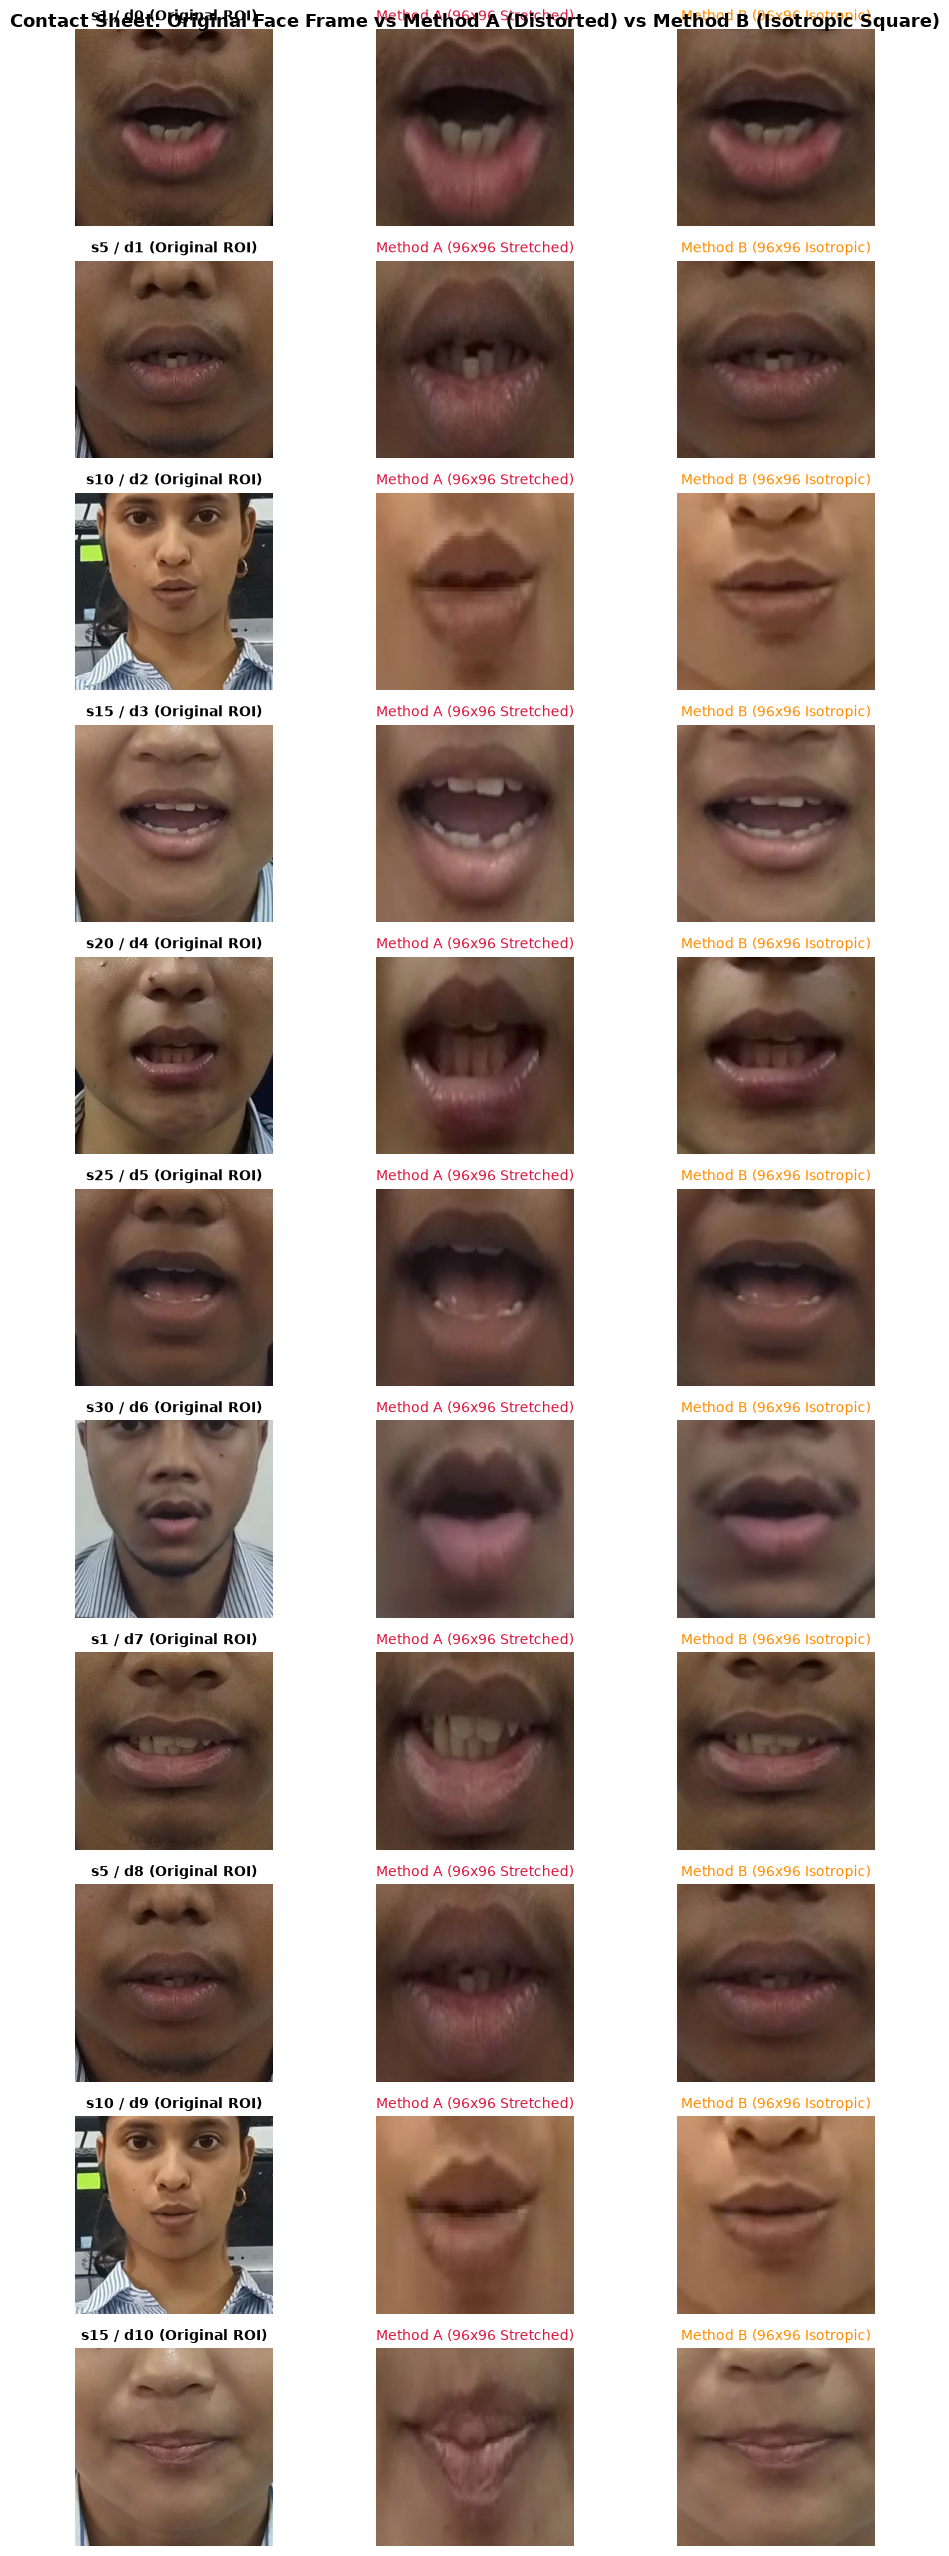

In [7]:
# Section 7: Multi-Speaker & All-Digits Contact Sheet
def get_method_a_crop(img, row):
    h_img, w_img = img.shape[:2]
    min_x = row["center_x"] - row["raw_width"] / 2.0
    max_x = row["center_x"] + row["raw_width"] / 2.0
    min_y = row["center_y"] - row["raw_height"] / 2.0
    max_y = row["center_y"] + row["raw_height"] / 2.0
    x1 = max(0, int(min_x - PAD_X))
    y1 = max(0, int(min_y - PAD_Y))
    x2 = min(w_img, int(max_x + PAD_X))
    y2 = min(h_img, int(max_y + PAD_Y))
    crop = img[y1:y2, x1:x2]
    return cv2.resize(crop, (96, 96), interpolation=cv2.INTER_AREA)

def get_method_b_crop(img, row):
    h_img, w_img = img.shape[:2]
    w_mouth = row["raw_width"] + 2 * PAD_X
    h_mouth = row["raw_height"] + 2 * PAD_Y
    side = int(round(max(w_mouth, h_mouth) * MARGIN_FACTOR))
    x1 = int(round(row["center_x"] - side / 2.0))
    y1 = int(round(row["center_y"] - side / 2.0))
    x2 = x1 + side
    y2 = y1 + side
    pad_top = max(0, -y1)
    pad_left = max(0, -x1)
    pad_bottom = max(0, y2 - h_img)
    pad_right = max(0, x2 - w_img)
    if pad_top > 0 or pad_left > 0 or pad_bottom > 0 or pad_right > 0:
        img_padded = cv2.copyMakeBorder(img, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_REFLECT)
        crop = img_padded[y1 + pad_top : y2 + pad_top, x1 + pad_left : x2 + pad_left]
    else:
        crop = img[y1:y2, x1:x2]
    return cv2.resize(crop, (96, 96), interpolation=cv2.INTER_AREA)

sample_frames = []
speakers_to_sample = ["s1", "s5", "s10", "s15", "s20", "s25", "s30"]

for idx, dig in enumerate([f"d{i}" for i in range(11)]):
    spk = speakers_to_sample[idx % len(speakers_to_sample)]
    sub = df_geom[(df_geom["speaker"] == spk) & (df_geom["digit"] == dig)]
    if len(sub) > 0:
        mid_idx = len(sub) // 2
        sample_frames.append(sub.iloc[mid_idx])

fig, axes = plt.subplots(11, 3, figsize=(10, 26))
plt.subplots_adjust(top=0.96, hspace=0.35, wspace=0.15)

for idx, row in enumerate(sample_frames):
    img = cv2.imread(str(PROJECT_ROOT / row["path"]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    cx, cy = int(row["center_x"]), int(row["center_y"])
    roi_face = img_rgb[max(0, cy - 120) : min(img.shape[0], cy + 120), max(0, cx - 120) : min(img.shape[1], cx + 120)]
    
    crop_a = cv2.cvtColor(get_method_a_crop(img, row), cv2.COLOR_BGR2RGB)
    crop_b = cv2.cvtColor(get_method_b_crop(img, row), cv2.COLOR_BGR2RGB)
    
    axes[idx, 0].imshow(roi_face)
    axes[idx, 0].set_title(f"{row['speaker']} / {row['digit']} (Original ROI)", fontsize=10, fontweight="bold")
    axes[idx, 0].axis("off")
    
    axes[idx, 1].imshow(crop_a)
    axes[idx, 1].set_title(f"Method A (96x96 Stretched)", fontsize=10, color="crimson")
    axes[idx, 1].axis("off")
    
    axes[idx, 2].imshow(crop_b)
    axes[idx, 2].set_title(f"Method B (96x96 Isotropic)", fontsize=10, color="darkorange")
    axes[idx, 2].axis("off")

plt.suptitle("Contact Sheet: Original Face Frame vs Method A (Distorted) vs Method B (Isotropic Square)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "contact_sheet_all_digits_method_comparison.png", dpi=300)
plt.show()

## 8. Temporal Speech Dynamics: Sequence Contact Sheet (s1 / d0)

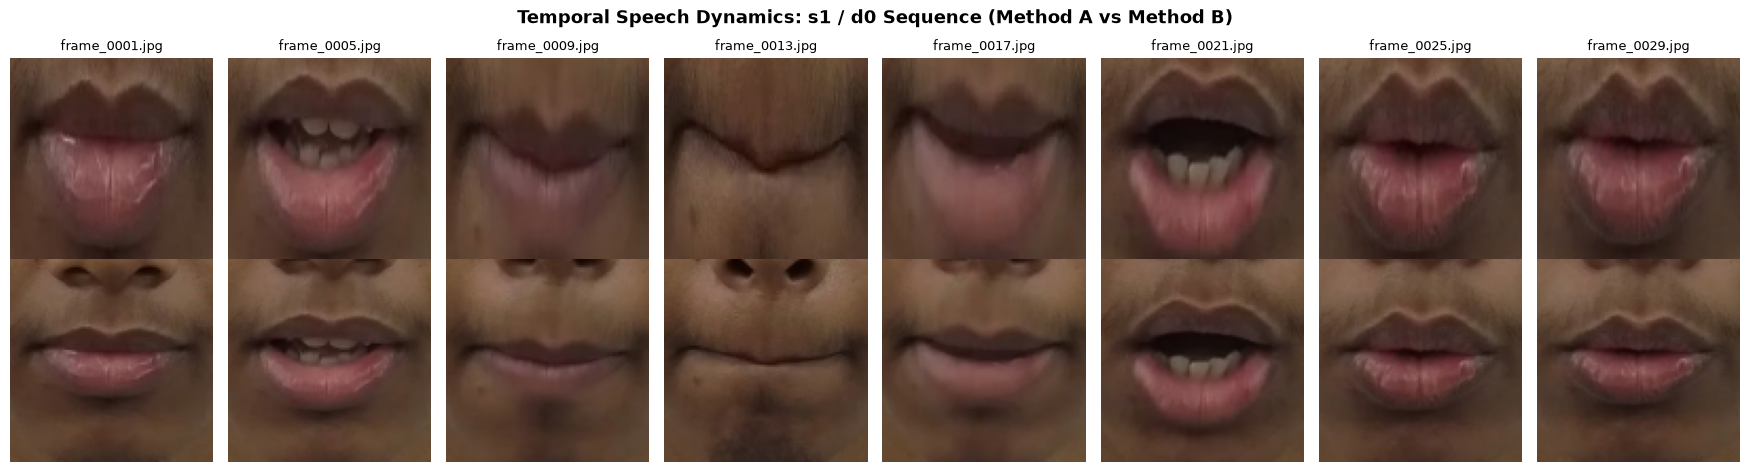

In [8]:
# Section 8: Temporal Sequence Contact Sheet
seq_rows = df_geom[(df_geom["speaker"] == "s1") & (df_geom["digit"] == "d0")].sort_values("frame").iloc[::4]
num_seq = min(8, len(seq_rows))
seq_rows = seq_rows.iloc[:num_seq]

fig, axes = plt.subplots(2, num_seq, figsize=(2.2 * num_seq, 4.8))
for col_idx, (_, row) in enumerate(seq_rows.iterrows()):
    img = cv2.imread(str(PROJECT_ROOT / row["path"]))
    crop_a = cv2.cvtColor(get_method_a_crop(img, row), cv2.COLOR_BGR2RGB)
    crop_b = cv2.cvtColor(get_method_b_crop(img, row), cv2.COLOR_BGR2RGB)
    
    axes[0, col_idx].imshow(crop_a)
    axes[0, col_idx].set_title(row["frame"], fontsize=9)
    axes[0, col_idx].axis("off")
    
    axes[1, col_idx].imshow(crop_b)
    axes[1, col_idx].axis("off")

axes[0, 0].set_ylabel("Method A\n(96×96 Distorted)", fontsize=10, fontweight="bold", color="crimson")
axes[1, 0].set_ylabel("Method B\n(96×96 Isotropic)", fontsize=10, fontweight="bold", color="darkorange")

plt.suptitle("Temporal Speech Dynamics: s1 / d0 Sequence (Method A vs Method B)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "temporal_sequence_method_b_comparison.png", dpi=300)
plt.show()

## 9. Method B Conclusions & Geometric Observations

1. **Successful Generation**:
   - Processed all $330$ utterances and $13,610$ frames ($100\%$ success rate, $0$ failures).
   - Saved cleanly to `data/cropped_lips_dataset_b_96x96/`.
2. **Preservation of Natural Aspect Ratio**:
   - Zero geometric elongation: lips remain natural without vertical stretching.
3. **Trade-off Analysis (Method A vs Method B)**:
   - **Method A**: Tight focus on lips, but distorted aspect ratio by $>40\%$.
   - **Method B**: Zero distortion and standard square input ($96\times 96$), but includes extra vertical context (nostrils and chin) due to expanding height to match width.